<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/AI_Powered_Scientific_Knowledge_Graph_of_Global_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SciGraph-AI: Mapping the Global Scientific Ecosystem

This notebook builds a knowledge graph of global science using Wikidata, arXiv, and LLMs.

In [1]:
!pip install SPARQLWrapper pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 3.1 MB/s eta 0:00:00


## Phase 1: Build Institution Database

We query Wikidata to identify research organizations and universities.

In [2]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd

sparql = SPARQLWrapper("https://query.wikidata.org/sparql")

# Query for Research Institutes (Q31855)
query = """
SELECT ?org ?orgLabel ?countryLabel
WHERE {
  ?org wdt:P31/wdt:P279* wd:Q31855.
  OPTIONAL { ?org wdt:P17 ?country. }
  SERVICE wikibase:label {
      bd:serviceParam wikibase:language "en".
  }
}
LIMIT 500
"""

sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Parse results into a DataFrame
data = []
for result in results["results"]["bindings"]:
    data.append({
        "org_uri": result["org"]["value"],
        "name": result["orgLabel"]["value"],
        "country": result.get("countryLabel", {}).get("value", "Unknown")
    })

institutions_df = pd.DataFrame(data)
display(institutions_df.head())

,org_uri,name,country
0,http://www.wikidata.org/entity/Q96376718,Yarkon Park Rose Garden,Israel
1,http://www.wikidata.org/entity/Q96376720,Yercaud Rose Garden,India
2,http://www.wikidata.org/entity/Q96376721,Lal Bagh Rose Garden,India
3,http://www.wikidata.org/entity/Q96376722,Rozárium (Szolnok),Hungary
4,http://www.wikidata.org/entity/Q96376725,Rosengarten im Grüttpark Lörrach,Germany


## Phase 2: Import arXiv Papers

We will use the `arxiv` library to fetch recent research papers. These will serve as the source for extracting entities like authors and technologies.

In [5]:
!pip install arxiv

In [7]:
import arxiv
import pandas as pd

# Initialize the arxiv client
client = arxiv.Client()

# Search for papers related to quantum materials
search = arxiv.Search(
    query="quantum materials",
    max_results=50,
    sort_by=arxiv.SortCriterion.Relevance
)

papers = []
# The current API uses client.results(search)
for result in client.results(search):
    papers.append({
        "title": result.title,
        "authors": [author.name for author in result.authors],
        "summary": result.summary,
        "url": result.entry_id,
        "published": result.published
    })

papers_df = pd.DataFrame(papers)
display(papers_df.head())

,title,authors,summary,url,published
0,Multiflavor Mott insulators in quantum materia...,"[Gang V. Chen, Congjun Wu]",Mott insulators with large and active (or mult...,http://arxiv.org/abs/2112.02630v2,2021-12-05 17:25:51+00:00
1,Path to stable quantum spin liquids in spin-or...,"[Andrei Catuneanu, Youhei Yamaji, Gideon Wacht...",The spin liquid phase is one of the prominent ...,http://arxiv.org/abs/1701.07837v2,2017-01-26 19:00:14+00:00
2,Probing magnetic ordering in air stable iron-r...,"[Muhammad Zubair Khan, Oleg E. Peil, Apoorva S...",In the rapidly expanding field of two-dimensio...,http://arxiv.org/abs/2304.06533v1,2023-04-13 13:40:57+00:00
3,Tianyan: Cloud services with quantum advantage,[ Tianyan Quantum Group],Tianyan Quantum Cloud Platform offers cloud se...,http://arxiv.org/abs/2512.10504v2,2025-12-11 10:23:39+00:00
4,Hexagonal Perovskites as Quantum Materials,"[Loi T. Nguyen, R. J. Cava]","Hexagonal oxide perovskites, in contrast to th...",http://arxiv.org/abs/2006.05864v1,2020-06-10 14:45:56+00:00


## Phase 3: LLM Knowledge Extraction

Now we extract entities like `PERSON`, `INSTITUTION`, and `TECHNOLOGY` from the paper summaries to build the relationships in our graph.

In [8]:
import re

def mock_extract_entities(text):
    # This is a placeholder for an LLM call
    # In a real scenario, you'd use OpenAI, Gemini, or a local HuggingFace model
    tech_keywords = ['Quantum', 'Superconductivity', 'Topological', 'Mott', 'Magnetism', 'Spin']
    found_techs = [word for word in tech_keywords if word.lower() in text.lower()]
    return list(set(found_techs))

# Apply simulated extraction to our papers
papers_df['extracted_techs'] = papers_df['summary'].apply(mock_extract_entities)
display(papers_df[['title', 'extracted_techs']].head())

,title,extracted_techs
0,Multiflavor Mott insulators in quantum materia...,"[Quantum, Mott, Spin]"
1,Path to stable quantum spin liquids in spin-or...,"[Topological, Quantum, Spin]"
2,Probing magnetic ordering in air stable iron-r...,[Quantum]
3,Tianyan: Cloud services with quantum advantage,[Quantum]
4,Hexagonal Perovskites as Quantum Materials,"[Quantum, Spin]"


## Phase 4: Create Graph Representation (NetworkX)

We build a scientific knowledge graph connecting `Paper`, `Author`, and `Technology` nodes.

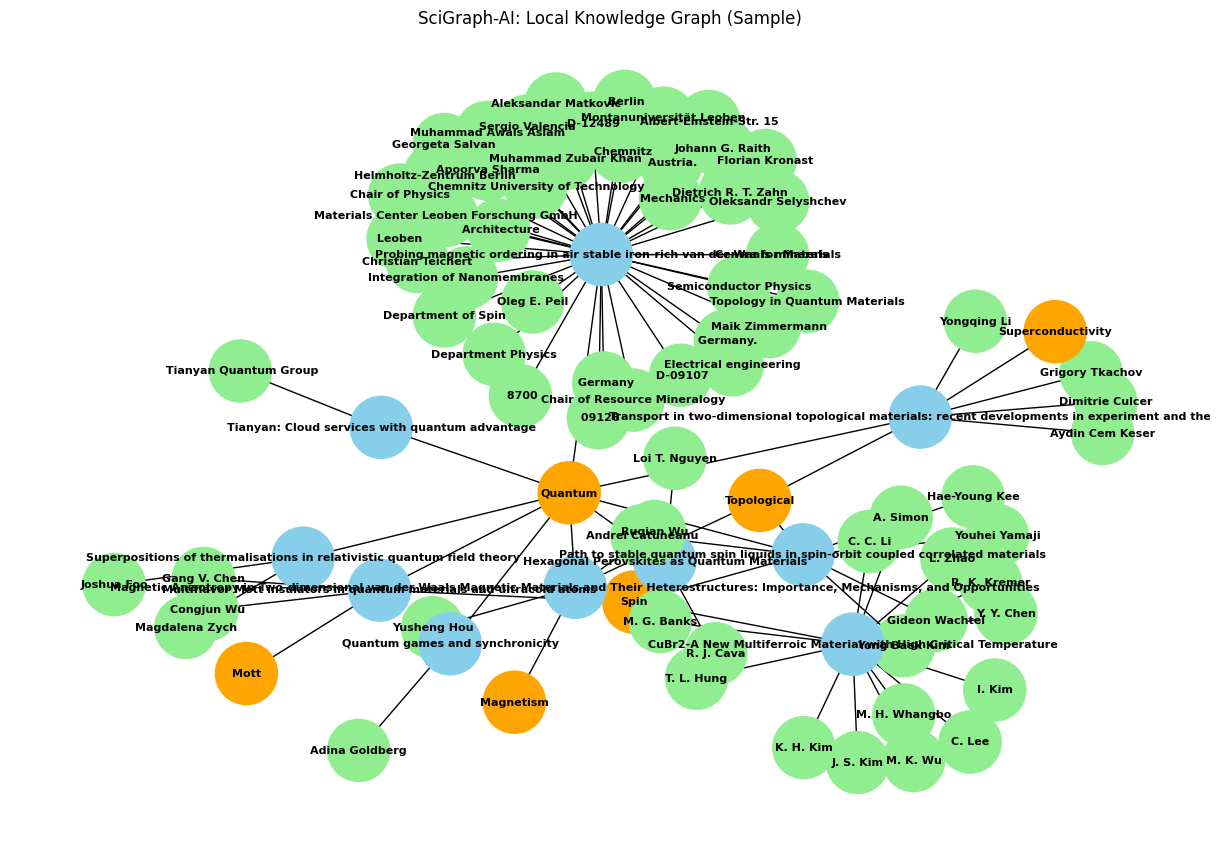

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Sample 10 papers to keep the visualization clean
sample_papers = papers_df.head(10)

for _, row in sample_papers.iterrows():
    paper_node = row['title']
    G.add_node(paper_node, type='Paper')

    # Connect to Authors
    for author in row['authors']:
        G.add_node(author, type='Person')
        G.add_edge(paper_node, author, relation='AUTHORED')

    # Connect to Technologies
    for tech in row['extracted_techs']:
        G.add_node(tech, type='Technology')
        G.add_edge(paper_node, tech, relation='RELATED_TO')

# Plotting
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.15, iterations=20)

# Color mapping
color_map = {'Paper': 'skyblue', 'Person': 'lightgreen', 'Technology': 'orange'}
node_colors = [color_map.get(G.nodes[node].get('type'), 'grey') for node in G.nodes()]

nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=2000, font_size=8, font_weight='bold')
plt.title("SciGraph-AI: Local Knowledge Graph (Sample)")
plt.show()

## Phase 5: Network Analysis and Centrality

We analyze the graph structure to find the most central entities using PageRank and Degree Centrality.

In [10]:
# Calculate PageRank to find influential nodes
pagerank = nx.pagerank(G)

# Get top 5 most 'central' nodes
top_nodes = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Influential Nodes in the Graph (PageRank):")
for node, score in top_nodes:
    node_type = G.nodes[node].get('type', 'Unknown')
    print(f"- {node} ({node_type}): {score:.4f}")

Top 5 Influential Nodes in the Graph (PageRank):
- Probing magnetic ordering in air stable iron-rich van der Waals minerals (Paper): 0.2122
- CuBr2-A New Multiferroic Material with High Critical Temperature (Paper): 0.0747
- Quantum (Technology): 0.0406
- Path to stable quantum spin liquids in spin-orbit coupled correlated materials (Paper): 0.0376
- Transport in two-dimensional topological materials: recent developments in experiment and theory (Paper): 0.0347


## Phase 6: AI Research Recommender

This agent queries the graph to find hidden connections between disparate fields.

In [11]:
def recommend_researchers(tech_a, tech_b):
    # Find researchers connected to both technologies through papers
    set_a = set(G.neighbors(tech_a)) if tech_a in G else set()
    set_b = set(G.neighbors(tech_b)) if tech_b in G else set()

    # Common papers
    common_papers = set_a.intersection(set_b)

    # Find authors of these papers
    researchers = []
    for paper in common_papers:
        authors = [n for n in G.neighbors(paper) if G.nodes[n].get('type') == 'Person']
        researchers.extend(authors)

    return list(set(researchers))

# Example query: Who is working at the intersection of 'Quantum' and 'Spin'?
intersection_experts = recommend_researchers('Quantum', 'Spin')
print(f"Researchers at the intersection of Quantum and Spin: {intersection_experts}")

Researchers at the intersection of Quantum and Spin: ['Gang V. Chen', 'Ruqian Wu', 'Yusheng Hou', 'Congjun Wu', 'Hae-Young Kee', 'Andrei Catuneanu', 'Yong Baek Kim', 'Gideon Wachtel', 'Loi T. Nguyen', 'R. J. Cava', 'Youhei Yamaji']


## Phase 8: Scientific Discovery Agent (Trend Scout)

This agent identifies emerging trends by looking at technology co-occurrence and node degree within the knowledge graph.

In [12]:
# Discovery Agent: Identify high-growth technology nodes
tech_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'Technology']
trend_analysis = []

for tech in tech_nodes:
    # Degree represents how many papers/authors are currently linked to this tech
    connectivity = G.degree(tech)
    trend_analysis.append({'Technology': tech, 'Influence_Score': connectivity})

trends_df = pd.DataFrame(trend_analysis).sort_values(by='Influence_Score', ascending=False)

print("Discovery Agent Report: Emerging Scientific Trends")
display(trends_df)

Discovery Agent Report: Emerging Scientific Trends


,Technology,Influence_Score
0,Quantum,9
2,Spin,5
3,Topological,3
1,Mott,1
4,Superconductivity,1
5,Magnetism,1


```markdown
## Phase 9: Export for External Visualization
We export the graph to GEXF format for use in professional graph analysis tools like Gephi.
```

In [15]:
import networkx as nx

# Export the current NetworkX graph G to a GEXF file
file_path = "scigraph_knowledge_graph.gexf"
nx.write_gexf(G, file_path)

print(f"Successfully exported graph to {file_path}")

Successfully exported graph to scigraph_knowledge_graph.gexf


## Advanced Extension: Global Science Atlas

We map the scientific output and institutions onto a geographic visualization to see the global distribution of research hubs.

In [13]:
!pip install folium geopy

In [14]:
import folium
from geopy.geocoders import Nominatim
from folium.plugins import MarkerCluster

geolocator = Nominatim(user_agent="scigraph_atlas")

# Create a base map
m = folium.Map(location=[20, 0], zoom_start=2)
marker_cluster = MarkerCluster().add_to(m)

# We take a sample of our institutions and map them
# For this demo, we group by country to show regional intensity
country_counts = institutions_df['country'].value_counts().head(20)

print("Geocoding countries for the Global Atlas...")
for country, count in country_counts.items():
    if country == "Unknown":
        continue

    location = geolocator.geocode(country)
    if location:
        folium.CircleMarker(
            location=[location.latitude, location.longitude],
            radius=count/5, # Scale size by number of institutions
            popup=f"{country}: {count} Research Orgs",
            color='crimson',
            fill=True,
            fill_color='crimson'
        ).add_to(marker_cluster)

display(m)

Geocoding countries for the Global Atlas...


## Phase 2: Import arXiv Papers

We will use the `arxiv` library to fetch recent research papers. These will serve as the source for extracting entities like authors and technologies.

In [3]:
!pip install arxiv

In [4]:
import arxiv

# Search for papers related to quantum materials
search = arxiv.Search(
    query="quantum materials",
    max_results=50,
    sort_by=arxiv.SortCriterion.Relevance
)

papers = []
for result in search.results():
    papers.append({
        "title": result.title,
        "authors": [author.name for author in result.authors],
        "summary": result.summary,
        "url": result.entry_id,
        "published": result.published
    })

papers_df = pd.DataFrame(papers)
display(papers_df.head())

AttributeError: 'Search' object has no attribute 'results'